In [31]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.integrate import odeint
from scipy.fftpack import diff as psdiff

from mpl_toolkits.mplot3d import Axes3D

It takes about 2 mins to run through the whole notebook on colab.

---
# 1. An Introduction to Lorenz63 Model

The Lorenz 63 model, formulated by Edward Lorenz in 1963, represents a milestone in atmospheric science and  nonlinear dynamics. It introduced the foundational concept of 'chaos', demonstrating that in some nonlinear systems, a minor perturbation in initial conditions will lead to very different trajecories (Lorenz E N. 1963). This profound insight implies that the predictability of a dynamic system has a theoretical limit, thereby in atmospheric science shifting the paradigm of numerical weather prediction from purely deterministic forecasts to probabilistic ensembles.

This model is derived from a Boussinesq system in only x- and z-axis, which can be seen as a convection problem, i.e.
\begin{equation*}
\frac{\partial}{\partial t} \nabla^2 \psi = - J(\psi, \nabla^2 \psi) + \nu \nabla^4 \psi + g\alpha \frac{\partial \theta}{\partial x}, \qquad(1)
\end{equation*}

\begin{equation*}
\frac{\partial}{\partial t} \theta = - J(\psi, \theta) + \frac{\Delta T}{H} \frac{\partial \psi}{\partial x} + \kappa\nabla^2 \theta, \qquad(2)
\end{equation*}

where $\psi$ is a stream function for the two-dimensional motion and $\theta$ is the departure of temperature from the state without convection.

To simplify the nonlinear equations, we can let
\begin{equation*}
a(1+a^2)^{-1}\kappa^{-1}\psi = X(t)\sqrt{2}\sin(\pi a L^{-1}x)\sin(\pi H^{-1}z), \qquad(3)
\end{equation*}

\begin{equation*}
\pi R_c^{-1}R_a\Delta T^{-1} \theta = Y(t)\sqrt{2} \cos(\pi a L^{-1}x) \sin(\pi H^{-1} z) - Z(t) \sin(2\pi H^{-1}z), \qquad(4)
\end{equation*}

where $a(1+a^2)^{-1}\kappa^{-1}$ and $\pi R_c^{-1}R_a\Delta T^{-1}$ are some constants we will discuss later. (3) and (4) can be regarded as the truncated Fourier expansion of the solution. By subtituting them into (1) and (2), the lorenz63 system becomes

\begin{equation*}
\dot{X} = \sigma (Y - X),
\end{equation*}

\begin{equation*}
\dot{Y} = - X (Z - \rho) - Y,
\end{equation*}

\begin{equation*}
\dot{Z} = XY - \beta Z.
\end{equation*}

The figure below shows one solution with classical parameters, The trajectory looks like a butterfly.

Text(0.5, 0, '$z(t)$')

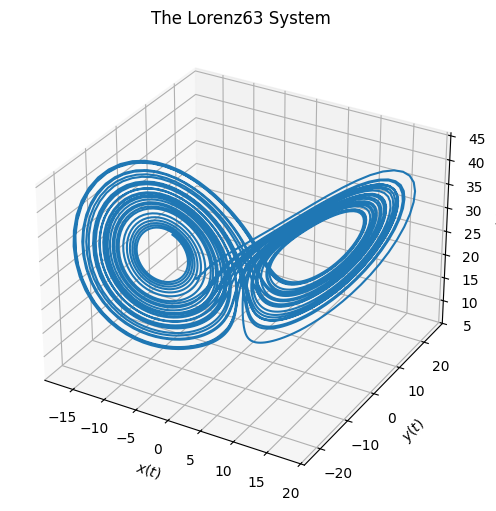

In [32]:
def lorenz63(t, state, sigma, rho, beta):
    x, y, z = state
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z
    return [dx, dy, dz]

state0 = [1.0, 1.0, 1.0]  # Initial state
params = (10.0, 28.0, 8.0/3.0)  # Classial arameters for sigma, rho, beta

t = np.linspace(0, 50, 5000)
sol = solve_ivp(lorenz63, [t[0], t[-1]], [0.1, 0.1, 0.1], t_eval=t, args=params)

x, y, z = sol.y
x = x[1000:]
y = y[1000:]
z = z[1000:]

fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection="3d")
ax.plot(x, y, z)
ax.set_title('The Lorenz63 System')
ax.set_xlabel(r"$x(t)$")
ax.set_ylabel(r"$y(t)$")
ax.set_zlabel(r"$z(t)$")


---
## 2. The physical meaning of varibles and parameters

### a) $X$, $Y$ and $Z$
As equations (3) and (4) show, $X$ is the amplitude of the stream function, while $Y$ and $Z$ are the amplitudes of potential temperature $\theta$ with different wavenumber. Thus, $X$ can be interpreted as the intensity of convective motion, and $Y$,$Z$ describe the temperature field.

### b) $\rho$
$\rho$ can be calculated from (4) as,

\begin{equation}
\rho = \frac{R_a}{R_c}, \\
R_a = \frac{g\alpha H^3\Delta T}{\nu \kappa}, \ R_c = \pi^4(1+a^2)^3/a^2,
\end{equation}

where $R_a$ is the Rayleigh number, the ratio of vertical convection to heat and momentum dispersion. Since $R_c$ only depends on wavenumber $a$, which can be seen as a scaling parameter, $\rho$ is called the rescaled Rayleigh number.

The analytical result shows that if $\rho \le 1$, the equation has only one stable equilibrium point $(0,0,0)$, and all trajectory will converge to this point (Algaba A, et al. 2014). In this case, the vertical temperature gradient is too weak to produce a convection. If $\rho > 1$, except for $(0,0,0)$, there are another two equilibrium points:

\begin{equation}
E_{\pm} = (\pm \sqrt{\beta (\rho - 1)}, \pm \sqrt{\beta (\rho - 1)}, \rho - 1).
\end{equation}

Then, we can analyse the stability of $E_{\pm}$. A Hopf bifurcation point occurs at,

\begin{equation}
\rho_H = \frac{\sigma(\sigma + \beta + 3)}{\sigma - \beta - 1}.
\end{equation}

If $1<\rho<\rho_H$, $E_{\pm}$ are stable, but $(0,0,0)$ is unstable, so the trajectory will converge to $E_+$ or $E_-$. When $\rho>\rho_H$, the Hopf bifurcation destabilizes $E_{\pm}$, and the system exhibits oscillatory behavior in which trajectories move irregularly between the neighborhoods of these two points. This mechanism leads to the 'butterfly' we saw before.




In [33]:
def lorenz63_equilibria(sigma, rho, beta):
    eq1 = np.array([0, 0, 0])
    if rho > 1:
        x = np.sqrt(beta * (rho - 1))
        eq2 = np.array([x, x, rho - 1])
        eq3 = np.array([-x, -x, rho - 1])
        return np.vstack([eq1, eq2, eq3])
    else:
        return np.vstack([eq1])

Text(0.5, 0.92, '$\\rho=28$')

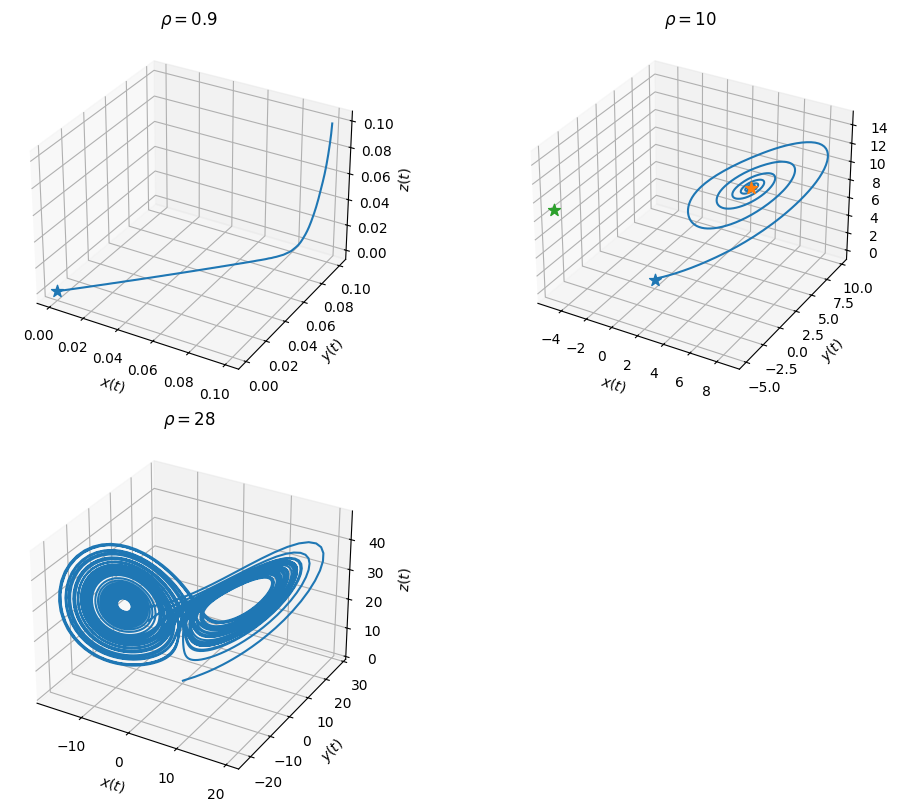

In [34]:
# change the parameter
fig = plt.figure(figsize=(10, 8), constrained_layout=True)
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], width_ratios=[1, 1])

ax0 = fig.add_subplot(gs[0, 0], projection="3d")

params = (10, 0.9, 8.0/3.0)  # sigma, rho, beta

sol = solve_ivp(lorenz63, [t[0], t[-1]], [0.1, 0.1, 0.1], t_eval=t, args=params)

x, y, z = sol.y

ax0.plot(x, y, z)
ax0.set_xlabel(r"$x(t)$")
ax0.set_ylabel(r"$y(t)$")
ax0.set_zlabel(r"$z(t)$")
ax0.set_title(r"$\rho=0.9$")

ax0.scatter(0, 0, 0, s=80,marker='*')

#-----

ax1 = fig.add_subplot(gs[0, 1], projection="3d")

params = (10, 10, 8.0/3.0)

eq = lorenz63_equilibria(params[0], params[1], params[2])

sol = solve_ivp(lorenz63, [t[0], t[-1]], [0.1, 0.1, 0.1], t_eval=t, args=params)

x, y, z = sol.y

ax1.plot(x, y, z)
ax1.set_xlabel(r"$x(t)$")
ax1.set_ylabel(r"$y(t)$")
ax1.set_zlabel(r"$z(t)$")
ax1.set_title(r"$\rho=10$")

ax1.scatter(eq[0, 0], eq[0, 1], eq[0, 2], s=80,marker='*')
ax1.scatter(eq[1, 0], eq[1, 1], eq[1, 2], s=80,marker='*')
ax1.scatter(eq[2, 0], eq[2, 1], eq[2, 2], s=80,marker='*')

#-----

ax2 = fig.add_subplot(gs[1, 0], projection="3d")

params = (10, 28, 8.0/3.0)

sol = solve_ivp(lorenz63, [t[0], t[-1]], [0.1, 0.1, 0.1], t_eval=t, args=params)

x, y, z = sol.y


ax2.plot(x, y, z)
ax2.set_xlabel(r"$x(t)$")
ax2.set_ylabel(r"$y(t)$")
ax2.set_zlabel(r"$z(t)$")
ax2.set_title(r"$\rho=28$")

#### c) $\sigma$ and $\beta$
$\sigma = \nu / \kappa$ is the Prandtl number, and $\beta = 4 / (1+a^2)$. These two parameters determine the dissipation rates of velocity and temperature modes, which influence the stability of equilibria and the flow in the phase space.

Since this assignment does not purely focus on the dynamical properties of lorenz63 system, more analysis about parameters wouldn't be discussed here. Hoewever, you can conduct experiments with different parameters on the following website, which was created by one of my friend ([@南鸽子](https://www.xiaohongshu.com/user/profile/671073c7000000001d033993?xsec_token=ABQOVIehiHh2TUoo2X2nKykVtLS-zMZWvRSvMxixGGFTw%3D&xsec_source=pc_search)).

In [35]:
from IPython.display import IFrame

IFrame('https://lorenz.ottoqwq.me/', width=800, height=600)

---
## 3. The Dynamic Clustering

In the preceding sections, the dynamical properties of the Lorenz63 system were analyzed directly from its governing equations. A natural inverse question then arises: given a time series or a trajectory in phase space, is it possible to infer some dynamical properties without prior knowledge of the underlying equations? More specifically in this case, one may ask whether it is possible to identify the dynamical region to which a given state belongs solely based on the model data. From a machine learning perspective, this problem can be formulated as a clustering task, where states are grouped according to similarities in their geometric or statistical characteristics. This approach helps clarify the relationship between dynamical structures of the Lorenz system and statistical patterns observed in its trajectories. It also provides an opportunity to assess the applicability of different clustering algorithms to dynamical systems.

### a) Labeling

In order to evaluate the accuracy of the clustering results, we should first label the data. Here, we follow the method adopted by A. N. Souza (A. N. Souza 2024), who employed a Voronoi tessellation over the full state space, $\mathbb{R}^3$. Specifically, the three equilibrium points are taken as the centers of the regions, and each state point is assigned to the group of the nearest equilibrium point according to Euclidean distance. Its dynamical meaning can be interpreted as examining which equilibrium point exerts the strongest influence on a given state in phase space.

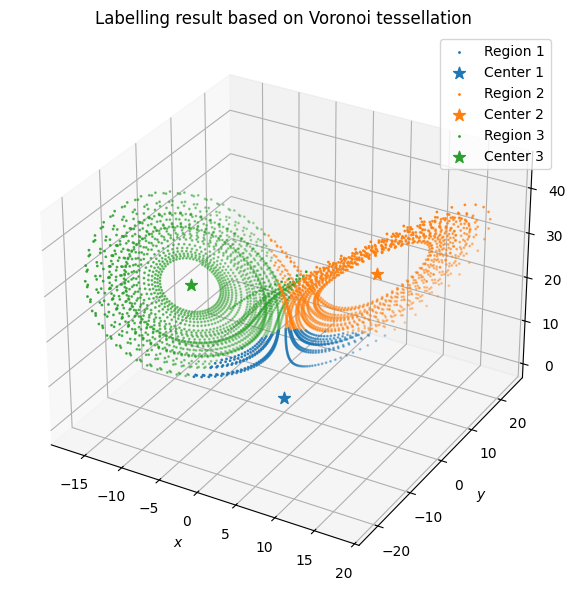

In [36]:
# labelling
equilibria = lorenz63_equilibria(params[0], params[1], params[2])

from scipy.spatial.distance import cdist

x = x[1000:]
y = y[1000:]
z = z[1000:]

data = np.column_stack((x, y, z))
point_labels = np.argmin(cdist(data, equilibria), axis=1)


def plot_cluster(data, point_labels, centers=None):
    fig = plt.figure(figsize=(7, 6))
    ax = plt.axes(projection="3d")
    colors = ['tab:blue', 'tab:orange', 'tab:green']
    for i in range(data.shape[1]):
        ax.scatter(data[point_labels == i, 0], data[point_labels == i, 1], data[point_labels == i, 2], s=1, color=colors[i], label=f"Region {i+1}")
        if centers is not None:
            ax.scatter(centers[i, 0], centers[i, 1], centers[i, 2], color=colors[i], s=80, marker='*', label=f'Center {i+1}')
        ax.set_xlabel(r"$x$")
        ax.set_ylabel(r"$y$")
        ax.set_zlabel(r"$z$")
    return fig, ax

fig, ax = plot_cluster(data, point_labels, equilibria)
ax.set_title("Labelling result based on Voronoi tessellation")
ax.legend()
plt.tight_layout()

### b) K-means in $\mathbb{R}^3$

K-means is a simple but widely used clustering algorithm. Here the number of clusters is set to three, corresponding to the number of groups defined above. The results show that K-means fails to correctly identify the dynamical regions. The wing of the 'butterfly' is artificially divided into two parts. This occurs because the algorithm relies solely on Euclidean distance in $\mathbb{R}^3$, whereas the Lorenz attractor possesses a lower dimensional geometric structure that cannot be captured by distances in the ambient Euclidean space alone.

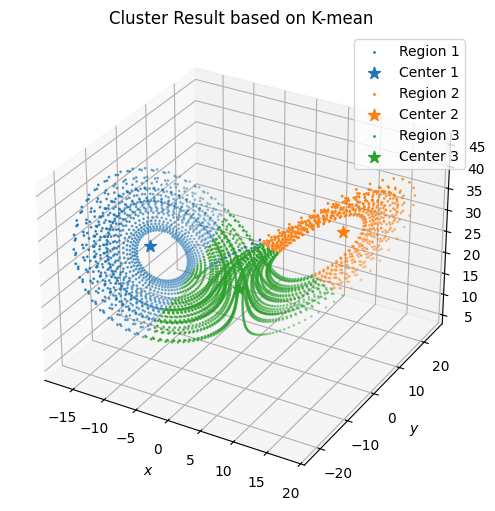

In [37]:
# K-mean
from sklearn.cluster import KMeans
original_data = data.copy()

n_clusters=3

model = KMeans(n_clusters=n_clusters, random_state=0)
model.fit(data)
labels = model.predict(data)

fig, ax = plot_cluster(data, labels, model.cluster_centers_)
ax.set_title("Cluster Result based on K-mean")
ax.legend()

A function is defined to calculate the accuracy of clustering. The quantitive result also demonstrates the inaccuracy of K-means.

In [38]:

from sklearn.metrics import accuracy_score
from scipy.optimize import linear_sum_assignment
from sklearn.utils import check_array

def best_accuracy_score(true_labels, pred_labels):
    true_labels = np.asarray(true_labels)
    pred_labels = np.asarray(pred_labels)
    D = max(true_labels.max(), pred_labels.max()) + 1  # class number
    w = np.zeros((D, D), dtype=np.int64)
    for i in range(true_labels.size):
        w[true_labels[i], pred_labels[i]] += 1
    ind = linear_sum_assignment(w.max() - w)       # Hungarian Algorithm
    return sum([w[i, j] for i, j in zip(*ind)]) / true_labels.size

kmeans_labels = labels
voronoi_labels = point_labels
accuracy = best_accuracy_score(voronoi_labels, kmeans_labels)
print(f"accuracy: {accuracy:.4f}")

accuracy: 0.5887


---
## 4. Manifold Learning

The results in Section 3 shows it is difficult to learn the structure of lorenz63 system in $\mathbb{R}^3$. As the system can be seen as a manifold, doing manifold learning before clustering may be a better choice.

### a) t-SNE

We first consider t-SNE. T-SNE focuses on preserving the local structure of the data. It constructs a probability distribution that represents similarities between points in the original high-dimensional space, where nearby points have a high probability of being neighbors,

\begin{equation*}
p_{j|i} = \frac{\exp{(-||x_i - x_j||^2/2\tau_i^2)}}{\sum_{k \ne i} \exp{(-||x_i - x_k||^2/2\tau_i^2)}}.
\end{equation*}

The algorithm then searches for a low-dimensional embedding where the similarities are modeled by a t-distribution, and optimizes this embedding so that the distribution can approximate the similarity distribution in the original space.



(This cell takes about 40 seconds to run.)

/tmp/ipykernel_422/1429608913.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(data_tsne[:, 0], data_tsne[:, 1], cmap="viridis", s=1)


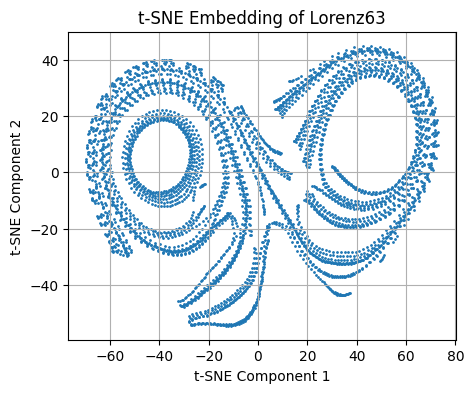

In [39]:
# tSNE embedding
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2, random_state=0)
data_tsne = tsne.fit_transform(original_data)
fig = plt.figure(figsize=(5, 4))
ax = plt.axes()
ax.scatter(data_tsne[:, 0], data_tsne[:, 1], cmap="viridis", s=1)
ax.set_xlabel("t-SNE Component 1")
ax.set_ylabel("t-SNE Component 2")
ax.set_title("t-SNE Embedding of Lorenz63")
ax.grid(True)

The t-SNE embedding shown above can roughly divide the Lorenz system into two parts, and applying K-means in the resulting $\mathbb{R}^2$ space yields a better clustering result.

accuracy: 0.7425


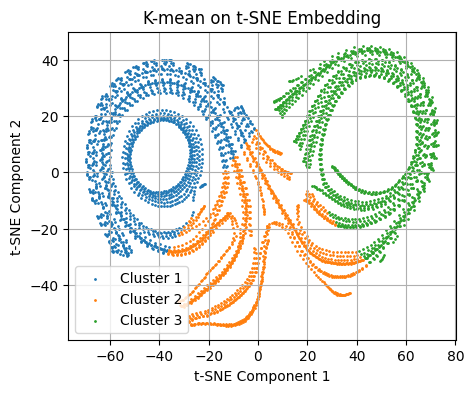

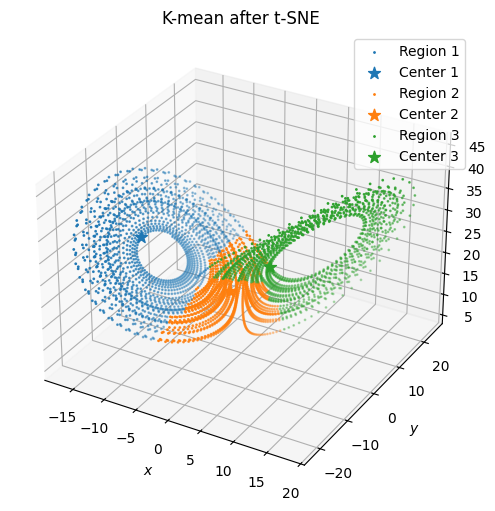

In [40]:
# K-means based on tSNE and mapping back to original space
import matplotlib.gridspec as gridspec

# K-means
model_tsne = KMeans(n_clusters=n_clusters, random_state=0)
model_tsne.fit(data_tsne)
labels_tsne = model_tsne.predict(data_tsne)

fig1 = plt.figure(figsize=(5,4))
ax1 = plt.axes()

for i in range(n_clusters):
    ax1.scatter(data_tsne[labels_tsne == i, 0], data_tsne[labels_tsne == i, 1], label=f"Cluster {i+1}", s=1)
ax1.set_xlabel("t-SNE Component 1")
ax1.set_ylabel("t-SNE Component 2")
ax1.set_title("K-mean on t-SNE Embedding")
ax1.grid(True)
ax1.legend()

cluster_centers_tsne = model_tsne.cluster_centers_

# Mapping the centers in t-SNE to the original space using Nearest Neighbor Search
from scipy.spatial import cKDTree
tree = cKDTree(data_tsne)
_, idx = tree.query(cluster_centers_tsne, k=1)
cluster_centers_original = original_data[idx]

fig2, ax2 = plot_cluster(original_data, labels_tsne, cluster_centers_original)
ax2.set_title("K-mean after t-SNE")
ax2.legend()

accuracy = best_accuracy_score(voronoi_labels, labels_tsne)
print(f"accuracy: {accuracy:.4f}")


## b) Spectral Clustering

The second algorithm we choose is Spectral Clustering. The basic idea of spectral clustering is to represent the dataset as a graph. In this graph, each data point is treated as a node, and nodes are connected according to their similarity (U Von Luxburg 2007).

The first step is to compute the similarity matrix. In scikit-learn, the default affinity is the RBF kernel,

\begin{equation*}
W_{ij} = \exp{(-\gamma ||x_i - x_j||^2)}.
\end{equation*}

This matrix is analogous to the probability matrix in t-SNE, where the matrix represents normalized neighborhood PDF. However, unlike t-SNE employs gradient descent to approximate the PDFs, spectral clustering uses eigenvalue decomposition to extract the principal pattern of data, and then map them to a lower-dimensional eigenspace.

After constructing the similarity matrix, we compute the Laplacian matrix,

\begin{equation*}
L = L(W),
\end{equation*}

which represents the connectivity structure of the graph.

Then, the first k eigenvectors $u_1, u_2, ..., u_k$ of $L$ is used to construct the basis of the new eigenspace. Each data point can be represented by these vectors, which gives a new representation of the data in a low-dimensional space.

The final step of spectral clustering is to apply K-means in this space as what we have done after t-SNE.

The results after Spectral Clustering show a subtle decrease in accuracy compared with t-SNE. The method is able to identify the structure of one attractor, but it struggles to correctly detect the region around (0,0,0). As a result, the structure of the other attractor cannot be accurately identified.

accuracy: 0.7400


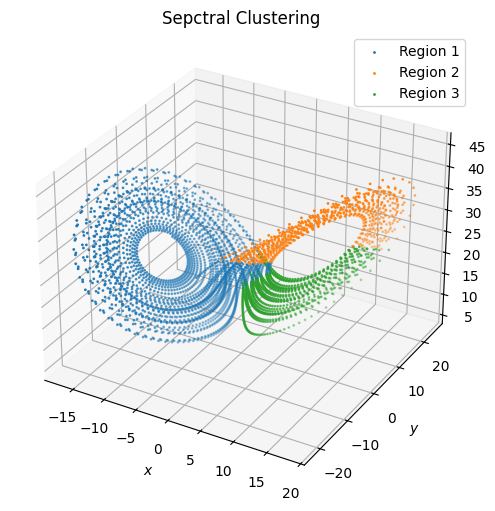

In [41]:
from sklearn.cluster import SpectralClustering
spcl_model = SpectralClustering(n_clusters=n_clusters, affinity='nearest_neighbors', random_state=0)
labels_spcl = spcl_model.fit_predict(original_data)

fig, ax = plot_cluster(original_data, labels_spcl, centers=None)
ax.set_title("Sepctral Clustering")
ax.legend()

accuracy = best_accuracy_score(voronoi_labels, labels_spcl)
print(f"accuracy: {accuracy:.4f}")



Since t-SNE performs well on the data from Lorenz 63 system, we also apply spectral clustering to the data after t-SNE (which can be seen as being embedded twice). The figure below shows the result obtained from the data generated on my own laptop. It achieves an excellent accuracy of 86%. The clustering result is shown following,

(This cell takes about 40 seconds to run.)

Downloading...
From: https://drive.google.com/uc?id=101x_FwlAemw7QrkAVsAl7tEByHrNIRXx
To: /content/lorenz63.txt
100%|██████████| 309k/309k [00:00<00:00, 79.9MB/s]
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


accuracy: 0.8648


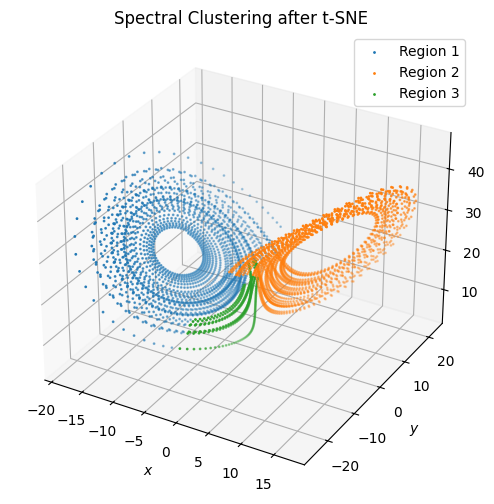

In [42]:
import gdown

try:
  url = 'https://drive.google.com/file/d/101x_FwlAemw7QrkAVsAl7tEByHrNIRXx/view?usp=drive_link'

  gdown.download(url, "lorenz63.txt", fuzzy=True)

  laptop_data = np.loadtxt("lorenz63.txt")

  laptop = TSNE(n_components=2, random_state=0)
  laptop_data_transform = laptop.fit_transform(laptop_data)

  spcl_model = SpectralClustering(n_clusters=n_clusters, affinity='nearest_neighbors', random_state=0)
  labels_spcl = spcl_model.fit_predict(laptop_data_transform)

  fig, ax = plot_cluster(laptop_data, labels_spcl, centers=None)
  ax.set_title("Spectral Clustering after t-SNE")
  ax.legend()

  accuracy = best_accuracy_score(voronoi_labels, labels_spcl)
  print(f"accuracy: {accuracy:.4f}")

except Exception as e:
    print("An error occurred while downloading or processing the data:")
    print(e)

However, running the same code on Google Colab does not produce the same accuracy. This difference arises because the numerical solutions are not identical across the two platforms, partly due to different versions of SciPy. This sensitivity suggests that the strategy of combining t-SNE with spectral clustering is not robust.

Nevertheless, across all results obtained using spectral clustering, the structure of at least one attractor can always be correctly identified. The accuracy mainly depends on how the points around (0,0,0) are treated. In contrast, directly applying k-means clustering fails to distinguish the structure of either lobe. This reveals that this manifold learning methods are able to capture the geometric structure of Lorenz63 system in three-dimensional space.



/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_spectral_embedding.py:329: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


accuracy: 0.7033


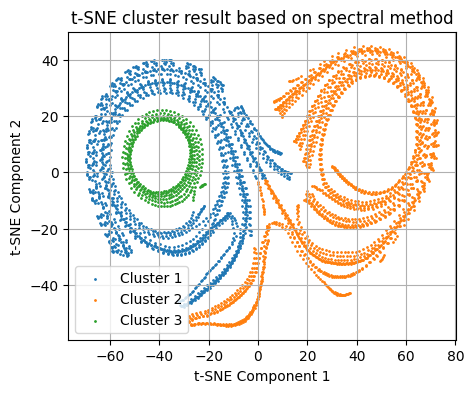

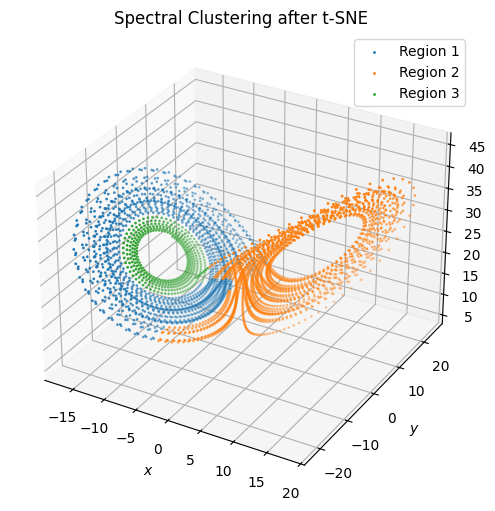

In [43]:
# Spectral clustering based on tSNE
spectral_model = SpectralClustering(n_clusters=n_clusters, affinity='nearest_neighbors', random_state=0)
labels_spectral = spectral_model.fit_predict(data_tsne)

fig1 = plt.figure(figsize=(5, 4))
ax1 = plt.axes()

for i in range(n_clusters):
    ax1.scatter(data_tsne[labels_spectral == i, 0], data_tsne[labels_spectral == i, 1], label=f"Cluster {i+1}", s=1)
ax1.set_xlabel("t-SNE Component 1")
ax1.set_ylabel("t-SNE Component 2")
ax1.set_title("t-SNE cluster result based on spectral method")
ax1.grid(True)
ax1.legend()

# Mapping back to original space
fig2, ax2 = plot_cluster(original_data, labels_spectral, centers=None)
ax2.set_title("Spectral Clustering after t-SNE")
ax2.legend()

accuracy = best_accuracy_score(voronoi_labels, labels_spectral)
print(f"accuracy: {accuracy:.4f}")

### c) Locally Linear Embedding (LLE)

Finally, we apply the Locally Linear Embedding (LLE) algorithm. LLE can be formulated through the following two optimization problems (Nakul Verma, 2018):

\begin{aligned}
&\underset{W}{\min} \Phi(W) = \sum_{i=1}^n ||x_i - \sum_{j \in N(i)} W_{ij} x_j||^2 \\
& \mathrm{s.t.} \forall i \sum_j W_{ij} = 1. \\
& w_{ij} = 0 \ \mathrm{where} \ j \notin N(i)
\end{aligned}

and,

\begin{aligned}
&\underset{Y}{\Psi(Y)} = \sum_{i=1} ^n ||y_i - \sum_{j \in N(i)} W_{ij} y_i ||^2 .\\
& \mathrm{s.t.} YY^T = I
\end{aligned}

It preserves local neighborhood relationships, but 'does not preserve the scale in the low-dimensional parametrization' (Nakul Verma, 2018). As a result, the geometric structure of Lorenz63 system become distorted in the embedding space. The resulting k-means clustering cannot produce a desirable classfication.

/tmp/ipykernel_422/2916624459.py:7: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(data_lle[:, 0], data_lle[:, 1], cmap="viridis", s=1)


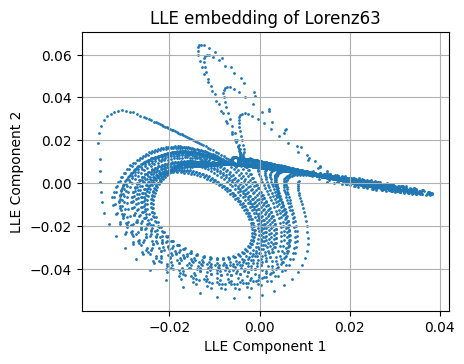

In [44]:
# Locally Linear Embedding (LLE)
from sklearn.manifold import LocallyLinearEmbedding
lle = LocallyLinearEmbedding(n_components=2, n_neighbors=10)
data_lle = lle.fit_transform(original_data)
fig = plt.figure(figsize=(5, 4))
ax = plt.axes()
ax.scatter(data_lle[:, 0], data_lle[:, 1], cmap="viridis", s=1)
ax.set_xlabel("LLE Component 1")
ax.set_ylabel("LLE Component 2")
ax.set_title("LLE embedding of Lorenz63")
ax.grid(True)
plt.tight_layout(pad=2)

accuracy: 0.6442


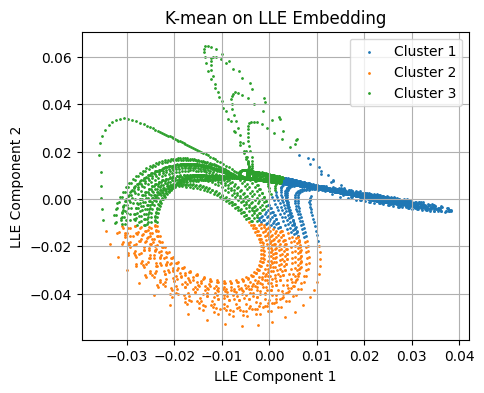

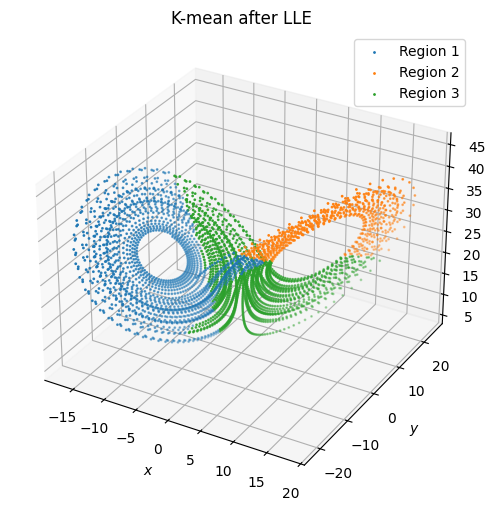

In [45]:
# K-means
model_lle = KMeans(n_clusters=n_clusters, random_state=0)
model_lle.fit(data_lle)
labels_lle = model_lle.predict(data_lle)
fig = plt.figure(figsize=(5, 4))
ax1 = plt.axes()
for i in range(n_clusters):
    ax1.scatter(data_lle[labels_lle == i, 0], data_lle[labels_lle == i, 1], label=f"Cluster {i+1}", s=1)
ax1.set_xlabel("LLE Component 1")
ax1.set_ylabel("LLE Component 2")
ax1.set_title("K-mean on LLE Embedding")
ax1.grid(True)
ax1.legend()

# Mapping back to original space
fig2, ax2 = plot_cluster(original_data, labels_lle)
ax2.set_title("K-mean after LLE")
ax2.legend()

accuracy = best_accuracy_score(voronoi_labels, labels_lle)
print(f"accuracy: {accuracy:.4f}")

## 4. Conclusion

In this assignment, we evaluated several clustering methods for identifying dynamical regions in trajectories of the Lorenz63 system. The results show that directly applying K-means clustering in the three-dimensional phase space performs poorly. Although the system evolves in ℝ³, its trajectories lie on a lower-dimensional attractor, whose geometric structure cannot be captured well by Euclidean distances.

Manifold learning methods provide a more suitable approach by projecting the data onto a lower-dimensional representation while preserving local structures. Among the tested methods, t-distributed Stochastic Neighbor Embedding (t-SNE) combined with K-means achieves the best accuracy and stability. Spectral Clustering can also reveal parts of the attractor structure, but its performance is less robust across different datasets. In contrast, Locally Linear Embedding (LLE) does not provide an effective embedding in this case, as the linear reconstruction distorts the underlying manifold structure.

## Reference:

Lorenz E N. The mechanics of vacillation[J]. Journal of Atmospheric Sciences, 1963, 20(5): 448-465.

Algaba A, Domínguez-Moreno M C, Merino M, et al. Study of the Hopf bifurcation in the Lorenz, Chen and Lü systems[J]. Nonlinear Dynamics, 2015, 79(2): 885-902.

Souza A N. Representing turbulent statistics with partitions of state space. Part 1. Theory and methodology[J]. Journal of Fluid Mechanics, 2024, 997: A1.

Von Luxburg U. A tutorial on spectral clustering[J]. Statistics and computing, 2007, 17(4): 395-416.

Zhong Z. Lecture 9: Non-Linear Dimensionality Reduction[R].
COMS 4995: Unsupervised Learning, Columbia University, 2018.


